# TODO:
* [x] move lattice code to class
* [x] add determination of specializer/generalizer; check implementation of specializer
* [ ] improve projection
* [ ] use KNN graph or graph from umap
* [x] Set color to scenario ID
* [x] Compute number of generalizers needed so that at least k specailizers exist per feature
* [x] Function to determine best specialization
* [ ] Weighted sum instead of minimax for generalizers; may be z-score normalize before weighted sum?; maybe show weighed sum as percentile?
* [x] use z-score or rank in PCP

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from importlib import reload 

In [2]:
import os

USER_PATH = '../../data/DataExchangeMilan_Project2.2a'
DATA_PATH = 'processed'

path = os.path.join(os.path.expanduser(USER_PATH), DATA_PATH)


os.listdir(path)

['mocodo_design_data.csv',
 'scenarios_wrevenues.csv',
 '.DS_Store',
 'scenarios_wrevenues_subset.csv',
 'design_solutions.csv',
 'mocodo_control_data.csv',
 'scenarios.csv',
 'MoCoDo formulation.docx',
 'design_solutions_per_scenario.csv']

# EDA Alternatives / Baselines

In [11]:
df_design = pd.read_csv(os.path.join(path, 'design_solutions_v0.csv'), index_col=0)
df_design

,Cable Capacity(MW),Battery Rated Power(MW),Cable Material Cost($M),Battery Cost($M),Day-Ahead Revenue ($k),Real-Time Revenue ($k),Reserve WF Revenue ($k),Reserve ESS Revenue ($k)
CCD18_3_cotwdpge,1991.029248,54.300003,200.495302,48.276124,1087.482856,19.060969,0.512244,1.076973
CCD18_3_johnday,2585.009992,70.499999,356.846697,62.678940,1360.725359,33.620576,0.651006,1.396229
CCD18_3_mossland,1980.003137,53.999993,406.362990,48.009396,960.079498,20.165528,0.456483,1.062219
CCD18_3_tesla,2904.001129,79.200000,544.461908,70.413789,1482.503741,39.052081,0.712933,1.571818
CCD18_3_wcascade,1650.006081,45.000000,279.352643,40.007835,914.059737,19.081562,0.420015,0.879943
CCD22_3_cotwdpge,1991.023489,90.499991,200.494722,80.460193,2534.572056,13.476278,0.603545,2.262833
CCD22_3_johnday,2585.003001,117.500000,356.845731,104.464902,3006.659806,23.054879,0.724474,2.789371
CCD22_3_mossland,1980.046451,89.999778,406.371879,80.015473,2106.973029,10.515738,0.533402,2.133969
CCD22_3_tesla,2904.004155,131.999982,544.462475,117.356300,3375.905789,7.844127,0.891775,3.230892
CCD22_3_wcascade,1650.006875,75.000000,279.352777,66.679725,2099.266635,20.578652,0.471774,1.818692


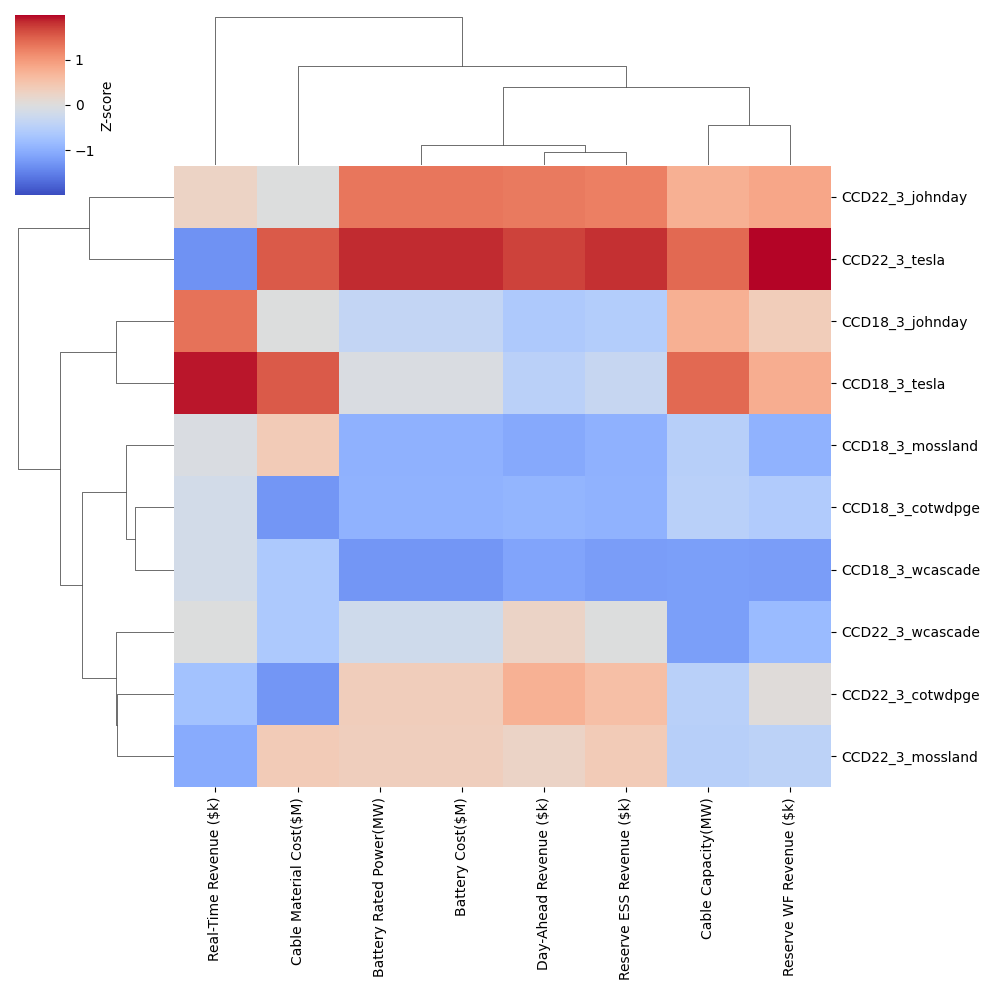

In [12]:
import seaborn as sns

df = df_design

X = (df - df.mean())/df.std()
vmax = vmax = X.abs().max().max()
vmin = -vmax
sns.clustermap(X, vmin=vmin, vmax=vmax, cmap='coolwarm', cbar_kws=dict(label='Z-score'))

# import matplotlib
# matplotlib.figure.Figure.colorbar.

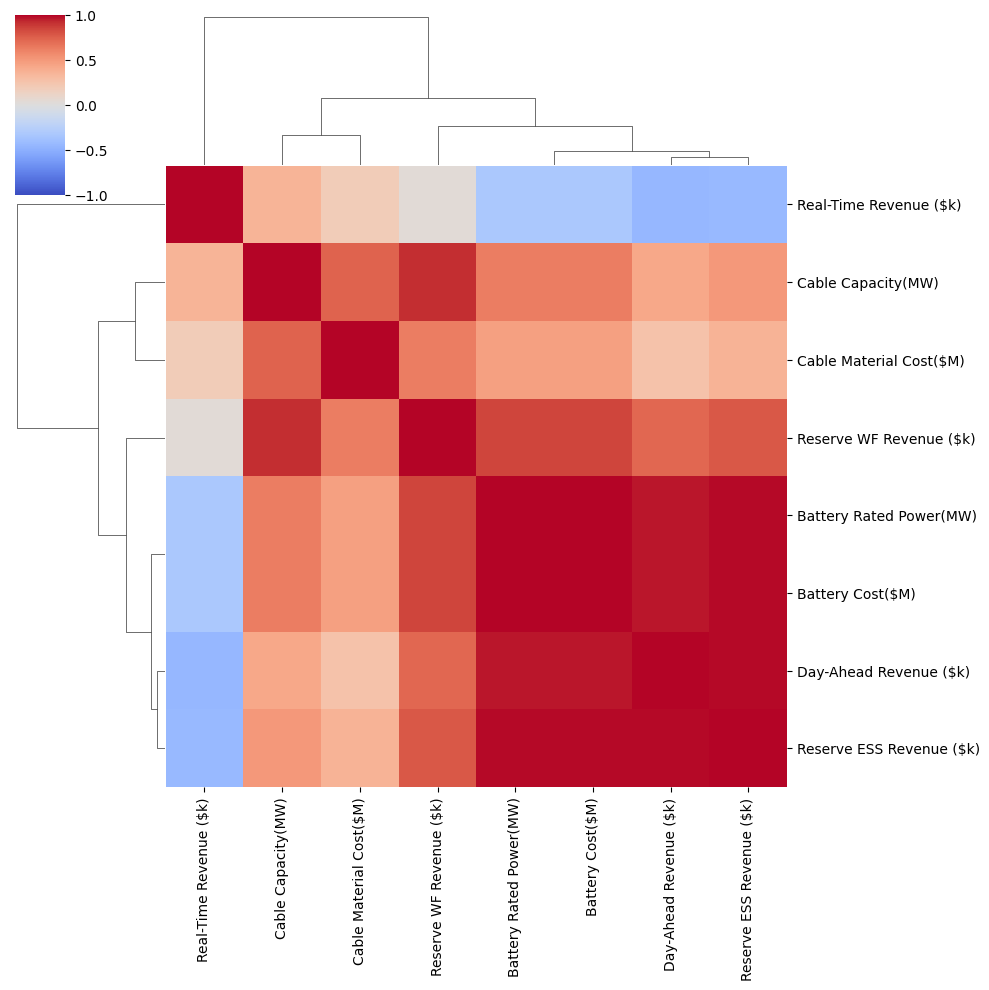

In [13]:
C = df.corr()
vmax = C.abs().max().max()
sns.clustermap(C, vmin=-vmax, vmax=vmax, cmap='coolwarm')

/Users/jain432/Library/CloudStorage/OneDrive-PNNL/Milan/Workspace/PNNL Projects/pyMOODS/venv/pymoods_mac/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jain432/Library/CloudStorage/OneDrive-PNNL/Milan/Workspace/PNNL Projects/pyMOODS/venv/pymoods_mac/lib/python3.13/site-packages/umap/umap_.py:2462: UserWarning: n_neighbors is larger than the dataset size; truncating to X.shape[0] - 1
  warn(


(np.float64(9.763458251953125),
 np.float64(12.811595916748047),
 np.float64(17.932597637176514),
 np.float64(19.865824222564697))

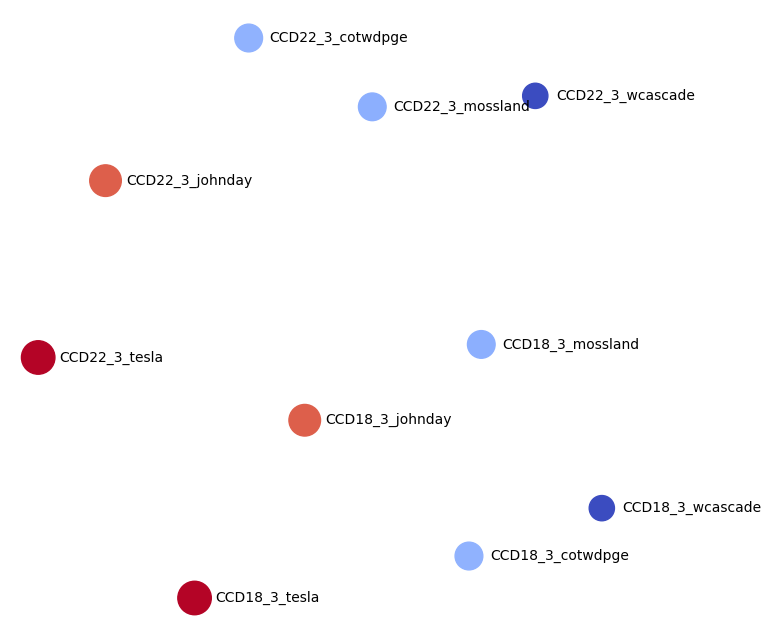

In [14]:
from umap import UMAP

by = df.columns[0]

plt.figure(figsize=(8, 8))

cmap = plt.cm.coolwarm
norm = plt.Normalize(-vmax, vmax)

pos = UMAP().fit_transform(X)
plt.scatter(*pos.T, s=df[by]/5, c=cmap(norm(X[by])))

for s, xy in zip(df.index, pos):
    plt.annotate(s, xy, va='center', xytext=(15, 0), textcoords='offset points')

plt.axis('off')


In [17]:
import tradeoff_lattice as tl; reload(tl)

df_design = pd.read_csv(os.path.join(path, 'design_solutions_v0.csv'), index_col=0)

ovars = [
    c
    for c in df_design.columns
    if '$' in c
]

def ovar_format(s):
    sep = ' Revenue'
    if ' Cost' in s:
        sep = ' Cost'

    left, right = s.split(sep)
    return f'{left}\n{sep[1:]}{right}'
    
ascending = [
    c
    for c in ovars
    if 'Cost' in c
]

dvars = set(df_design.columns).difference(ovars)

self = tl.DirectTradeoffLattice(
    df_design, ovars, dvars,
    ascending=ascending,
    # max_specializers=2,
    min_specializers=1,
    # n_generalizers=1,
)

In [18]:
self.rank

,Cable Material Cost($M),Battery Cost($M),Day-Ahead Revenue ($k),Real-Time Revenue ($k),Reserve WF Revenue ($k),Reserve ESS Revenue ($k)
CCD18_3_johnday,6.0,4.0,7.0,2.0,4.0,7.0
CCD18_3_cotwdpge,2.0,3.0,8.0,7.0,7.0,8.0
CCD22_3_cotwdpge,1.0,8.0,3.0,8.0,5.0,3.0
CCD22_3_wcascade,4.0,5.0,5.0,4.0,8.0,5.0
CCD18_3_mossland,7.0,2.0,9.0,5.0,9.0,9.0
CCD18_3_tesla,9.0,6.0,6.0,1.0,3.0,6.0
CCD22_3_johnday,5.0,9.0,2.0,3.0,2.0,2.0
CCD22_3_mossland,8.0,7.0,4.0,9.0,6.0,4.0
CCD18_3_wcascade,3.0,1.0,10.0,6.0,10.0,10.0
CCD22_3_tesla,10.0,10.0,1.0,10.0,1.0,1.0


In [19]:
self.df

,Cable Capacity(MW),Battery Rated Power(MW),Cable Material Cost($M),Battery Cost($M),Day-Ahead Revenue ($k),Real-Time Revenue ($k),Reserve WF Revenue ($k),Reserve ESS Revenue ($k)
CCD18_3_cotwdpge,1991.029248,54.300003,200.495302,48.276124,1087.482856,19.060969,0.512244,1.076973
CCD18_3_johnday,2585.009992,70.499999,356.846697,62.678940,1360.725359,33.620576,0.651006,1.396229
CCD18_3_mossland,1980.003137,53.999993,406.362990,48.009396,960.079498,20.165528,0.456483,1.062219
CCD18_3_tesla,2904.001129,79.200000,544.461908,70.413789,1482.503741,39.052081,0.712933,1.571818
CCD18_3_wcascade,1650.006081,45.000000,279.352643,40.007835,914.059737,19.081562,0.420015,0.879943
CCD22_3_cotwdpge,1991.023489,90.499991,200.494722,80.460193,2534.572056,13.476278,0.603545,2.262833
CCD22_3_johnday,2585.003001,117.500000,356.845731,104.464902,3006.659806,23.054879,0.724474,2.789371
CCD22_3_mossland,1980.046451,89.999778,406.371879,80.015473,2106.973029,10.515738,0.533402,2.133969
CCD22_3_tesla,2904.004155,131.999982,544.462475,117.356300,3375.905789,7.844127,0.891775,3.230892
CCD22_3_wcascade,1650.006875,75.000000,279.352777,66.679725,2099.266635,20.578652,0.471774,1.818692


In [20]:
self.ovars

['Cable Material Cost($M)',
 'Battery Cost($M)',
 'Day-Ahead Revenue ($k)',
 'Real-Time Revenue ($k)',
 'Reserve WF Revenue ($k)',
 'Reserve ESS Revenue ($k)']

In [29]:
self.scale

Cable Material Cost($M)    -1
Battery Cost($M)           -1
Day-Ahead Revenue ($k)      1
Real-Time Revenue ($k)      1
Reserve WF Revenue ($k)     1
Reserve ESS Revenue ($k)    1
dtype: int64

In [30]:
self.scale.to_dict()

{'Cable Material Cost($M)': -1,
 'Battery Cost($M)': -1,
 'Day-Ahead Revenue ($k)': 1,
 'Real-Time Revenue ($k)': 1,
 'Reserve WF Revenue ($k)': 1,
 'Reserve ESS Revenue ($k)': 1}

In [22]:
X.mean()

Cable Capacity(MW)         -2.886580e-16
Battery Rated Power(MW)     6.383782e-17
Cable Material Cost($M)    -1.110223e-17
Battery Cost($M)            2.886580e-16
Day-Ahead Revenue ($k)      3.413936e-16
Real-Time Revenue ($k)     -7.797582e-17
Reserve WF Revenue ($k)    -1.076916e-15
Reserve ESS Revenue ($k)   -1.073794e-16
dtype: float64

In [24]:
(self.df[ovars]*self.scale).rank(ascending=False)

,Cable Material Cost($M),Battery Cost($M),Day-Ahead Revenue ($k),Real-Time Revenue ($k),Reserve WF Revenue ($k),Reserve ESS Revenue ($k)
CCD18_3_cotwdpge,-200.495302,-48.276124,1087.482856,19.060969,0.512244,1.076973
CCD18_3_johnday,-356.846697,-62.678940,1360.725359,33.620576,0.651006,1.396229
CCD18_3_mossland,-406.362990,-48.009396,960.079498,20.165528,0.456483,1.062219
CCD18_3_tesla,-544.461908,-70.413789,1482.503741,39.052081,0.712933,1.571818
CCD18_3_wcascade,-279.352643,-40.007835,914.059737,19.081562,0.420015,0.879943
CCD22_3_cotwdpge,-200.494722,-80.460193,2534.572056,13.476278,0.603545,2.262833
CCD22_3_johnday,-356.845731,-104.464902,3006.659806,23.054879,0.724474,2.789371
CCD22_3_mossland,-406.371879,-80.015473,2106.973029,10.515738,0.533402,2.133969
CCD22_3_tesla,-544.462475,-117.356300,3375.905789,7.844127,0.891775,3.230892
CCD22_3_wcascade,-279.352777,-66.679725,2099.266635,20.578652,0.471774,1.818692


In [ ]:
if not use_rank:        
    X = self.df[self.ovars]*self.scale
    data = (X - X.mean())/X.std()

Cable Material Cost($M):  less --> more


RuntimeError: A legend label cannot be assigned to an Axis. Did you mean to set the axis label via set_label_text()?

<Figure size 800x800 with 0 Axes>

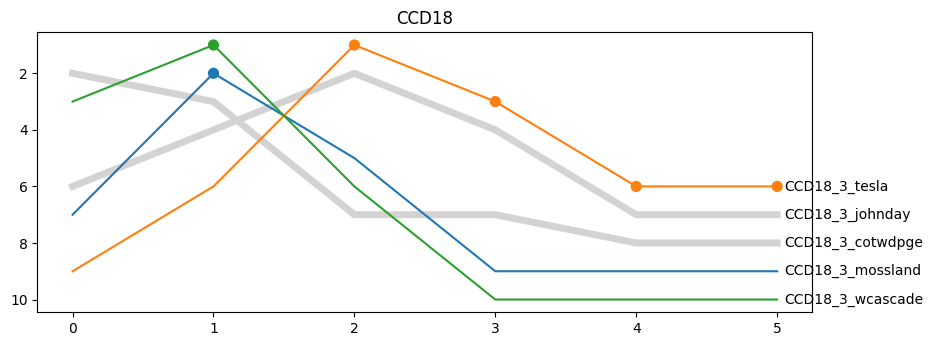

In [ ]:
by = ovars[0]

# plt.figure(figsize=(8, 8))
# plt.axis('off')
# self.draw(
#     by=by,
#     node_size=500,
#     with_edge_labels=self.dvars,
#     edge_labels_kwargs=dict(font_size=6, rotate=False),
#     node_labels_kwargs=dict(fontsize=8, fontweight='bold'),
#     show_negative=True,
#     show_positive=False,
# )

# plt.title(f'{by}:  less --> more')
print(f'{by}:  less --> more')
plt.savefig('design_solutions_tradeoffs_v0.pdf', format='pdf', bbox_inches='tight')

plt.figure(figsize=(10, 8))
self.plot_ovars_parallel_coords(
    x_label_format=ovar_format,
    use_rank=True,
    include_all_generalizers=True,
    facets = [
        i.split('_')[0]
        for i in self.rank.index
    ]
)

plt.subplots_adjust(hspace=.3)
# self.ovars_formatted()

In [16]:
self.rank.index

Index(['CCD18_3_johnday', 'CCD18_3_cotwdpge', 'CCD22_3_cotwdpge',
       'CCD22_3_wcascade', 'CCD18_3_mossland', 'CCD18_3_tesla',
       'CCD22_3_johnday', 'CCD22_3_mossland', 'CCD18_3_wcascade',
       'CCD22_3_tesla'],
      dtype='object')

# Larger Example

In [ ]:
import tradeoff_lattice as tl; reload(tl)

df_design = pd.read_csv(os.path.join(path, 'design_solutions.csv'), index_col=0)

def get_cluster_name(s):
    parts = s.split('_')
    return '_'.join([parts[0], parts[-1]])
    
ovars = [
    c
    for c in df_design.columns
    if '$' in c
]

ascending = [
    c
    for c in ovars
    if 'Cost' in c
]

dvars = set(df_design.columns).difference(ovars)

self = tl.DirectTradeoffLattice(
    df_design,
    ovars, dvars,
    ascending=ascending,
    max_specializers=5,
    # min_specializers=1,
    # n_generalizers=10,
)

by = ovars[0]

# plt.figure(figsize=(12, 24))
# plt.axis('off')
# plt.title(f'{by}:  less --> more')
# self.draw(
#     by=by,
#     node_size=500,
#     with_edge_labels=self.dvars,
#     edge_labels_kwargs=dict(font_size=6, rotate=False),
#     node_labels_kwargs=dict(fontsize=8, fontweight='bold')
# )

# plt.savefig('design_solutions_tradeoffs.pdf', format='pdf', bbox_inches='tight')

plt.figure(figsize=(10, 16))
self.plot_ovars_parallel_coords(
    x_label_format=ovar_format,
    use_rank=True,
    facets = [
        i.split('_')[0]
        for i in self.rank.index
    ]
)

plt.subplots_adjust(hspace=.5)